In [1]:
# ---- Standard-library imports ----
import pathlib  # resolve the downloaded dataset path
import random
import subprocess
import sys

# ---- Dataset loader (installed automatically on first use if missing) ----
try:
    import kagglehub
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True
    )
    import kagglehub

# ---- Data handling & plotting ----
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# ---- scikit-learn: preprocessing, selection & evaluation ----
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import label_binarize

# ---- Models ----
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ---- Reproducible project seed ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# Shared style so every chart looks the same (bold labels, 150 dpi).
plt.rcParams.update(
    {
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "figure.dpi": 150,
    }
)

# Consistent colors across plots.
PALETTE = ["#EA2027", "#006266", "#1B1464"]
CLASS_NAMES = ["Loss", "Low margin", "High margin"]

In [3]:
# TASK 1: Load & Explore Data
# (kagglehub downloads the dataset for us — no manual Drive upload needed)
path = kagglehub.dataset_download("himanshuuike/superstore-sales-dataset")
df = pd.read_csv(next(pathlib.Path(path).glob("*.csv")), encoding="latin1")
print(f"Shape: {df.shape}")
df.head()

Shape: (10194, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  str    
 6   Customer Name   10194 non-null  str    
 7   Segment         10194 non-null  str    
 8   Country/Region  10194 non-null  str    
 9   City            10194 non-null  str    
 10  State/Province  10194 non-null  str    
 11  Postal Code     10194 non-null  str    
 12  Region          10194 non-null  str    
 13  Product ID      10194 non-null  str    
 14  Category        10194 non-null  str    
 15  Sub-Category    10194 non-null  str    
 16  Product Name    10194 non-null  str    
 17  Sales           10194 non-null  float64
 1

In [5]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


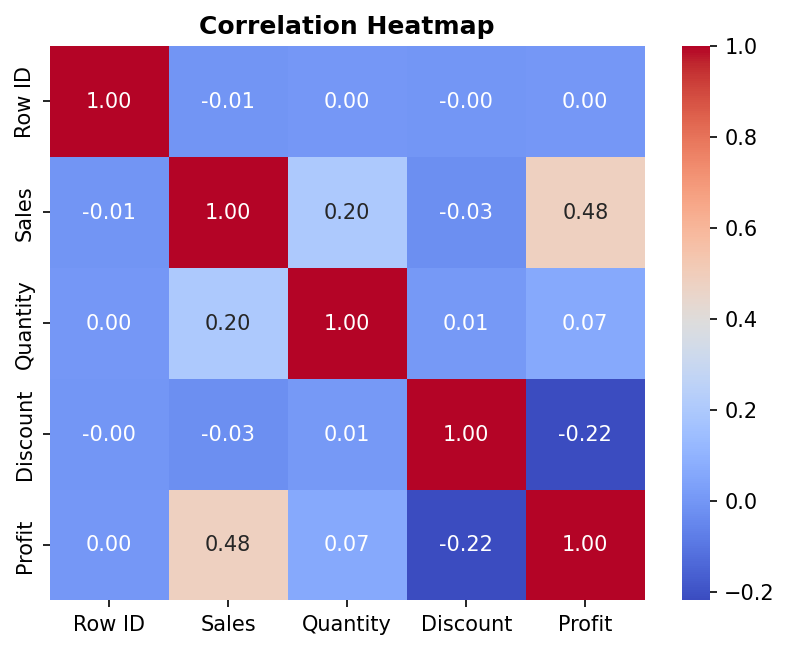

In [6]:
# Correlation heatmap (numeric columns only)
sns.heatmap(
    df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [7]:
# TASK 2: Clean Data
TARGET = "profit_class"

margin = df["Profit"] / df["Sales"]
df[TARGET] = np.select([df["Profit"] < 0, margin < 0.25], [0, 1], default=2)

features = [
    "Ship Mode",
    "Segment",
    "Region",
    "Category",
    "Sub-Category",
    "Sales",
    "Quantity",
    "Discount",
]
df = df[features + [TARGET]].drop_duplicates()
print(df[TARGET].value_counts())
df.head()

profit_class
2    5460
1    2435
0    1862
Name: count, dtype: int64


,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,profit_class
0,Standard Class,Consumer,Central,Office Supplies,Paper,16.448,2,0.2,2
1,Standard Class,Home Office,Central,Office Supplies,Binders,3.540,2,0.8,0
2,Standard Class,Home Office,Central,Office Supplies,Labels,11.784,3,0.2,2
3,Standard Class,Home Office,Central,Office Supplies,Storage,272.736,3,0.2,0
4,Standard Class,Consumer,East,Office Supplies,Art,19.536,3,0.2,2


In [8]:
# TASK 3: Preprocess
categorical_cols = ["Ship Mode", "Segment", "Region", "Category", "Sub-Category"]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df[features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (7805, 8) | Test: (1952, 8)


In [9]:
# TASK 4: Train Models
models = {
    "Random Forest": RandomForestClassifier(
        random_state=SEED,
        min_samples_leaf=2,
        max_features="sqrt",
    ),
    "Extra Trees": ExtraTreesClassifier(
        random_state=SEED,
        min_samples_leaf=2,
        max_features="sqrt",
    ),
    "XGBoost": XGBClassifier(random_state=SEED, eval_metric="mlogloss"),
    "LightGBM": LGBMClassifier(random_state=SEED),
    "CatBoost": CatBoostClassifier(random_state=SEED, verbose=0),
}

# Stacking uses a subset of the trees above as base learners.
models["Stacking"] = StackingClassifier(
    estimators=[
        (
            "rf",
            RandomForestClassifier(
                random_state=SEED,
                min_samples_leaf=2,
                max_features="sqrt",
            ),
        ),
        (
            "et",
            ExtraTreesClassifier(
                random_state=SEED,
                min_samples_leaf=2,
                max_features="sqrt",
            ),
        ),
        ("xgb", XGBClassifier(random_state=SEED, eval_metric="mlogloss")),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
)

trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

print("Training complete.")

Training Random Forest...
Training Extra Trees...
Training XGBoost...
Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000444 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 313
[LightGBM] [Info] Number of data points in the train set: 7805, number of used features: 8
[LightGBM] [Info] Start training from score -1.656660
[LightGBM] [Info] Start training from score -1.387961
[LightGBM] [Info] Start training from score -0.580459
Training CatBoost...
Training Stacking...
Training complete.


In [10]:
# TASK 5: Evaluate
results = []
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (macro)": precision_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "Recall (macro)": recall_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "F1 (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "Precision (weighted)": precision_score(
                y_test, y_pred, average="weighted", zero_division=0
            ),
            "Recall (weighted)": recall_score(
                y_test, y_pred, average="weighted", zero_division=0
            ),
            "F1 (weighted)": f1_score(
                y_test, y_pred, average="weighted", zero_division=0
            ),
            "ROC-AUC": roc_auc_score(
                y_test_bin, y_proba, average="macro", multi_class="ovr"
            ),
        }
    )

    print("=" * 55)
    print(f"{name} Classification Report")
    print("=" * 55)
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

Random Forest Classification Report
              precision    recall  f1-score   support

        Loss     0.8824    0.8043    0.8415       373
  Low margin     0.6974    0.7290    0.7129       487
 High margin     0.9102    0.9194    0.9148      1092

    accuracy                         0.8499      1952
   macro avg     0.8300    0.8176    0.8231      1952
weighted avg     0.8518    0.8499    0.8504      1952

Extra Trees Classification Report
              precision    recall  f1-score   support

        Loss     0.9091    0.7775    0.8382       373
  Low margin     0.6715    0.6591    0.6653       487
 High margin     0.8771    0.9277    0.9016      1092

    accuracy                         0.8320      1952
   macro avg     0.8192    0.7881    0.8017      1952
weighted avg     0.8319    0.8320    0.8305      1952

XGBoost Classification Report
              precision    recall  f1-score   support

        Loss     0.8509    0.8418    0.8464       373
  Low margin     0.7308    0.

In [11]:
comparison_df = (
    pd.DataFrame(results).round(4).sort_values("F1 (macro)", ascending=False)
)
comparison_df

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),ROC-AUC
2,XGBoost,0.8596,0.8336,0.8308,0.8322,0.8591,0.8596,0.8594,0.9658
5,Stacking,0.8566,0.8368,0.8245,0.8302,0.8567,0.8566,0.8564,0.9630
3,LightGBM,0.8550,0.8318,0.8263,0.8289,0.8554,0.8550,0.8551,0.9655
4,CatBoost,0.8499,0.8269,0.8220,0.8243,0.8501,0.8499,0.8500,0.9616
0,Random Forest,0.8499,0.8300,0.8176,0.8231,0.8518,0.8499,0.8504,0.9583
1,Extra Trees,0.8320,0.8192,0.7881,0.8017,0.8319,0.8320,0.8305,0.9534


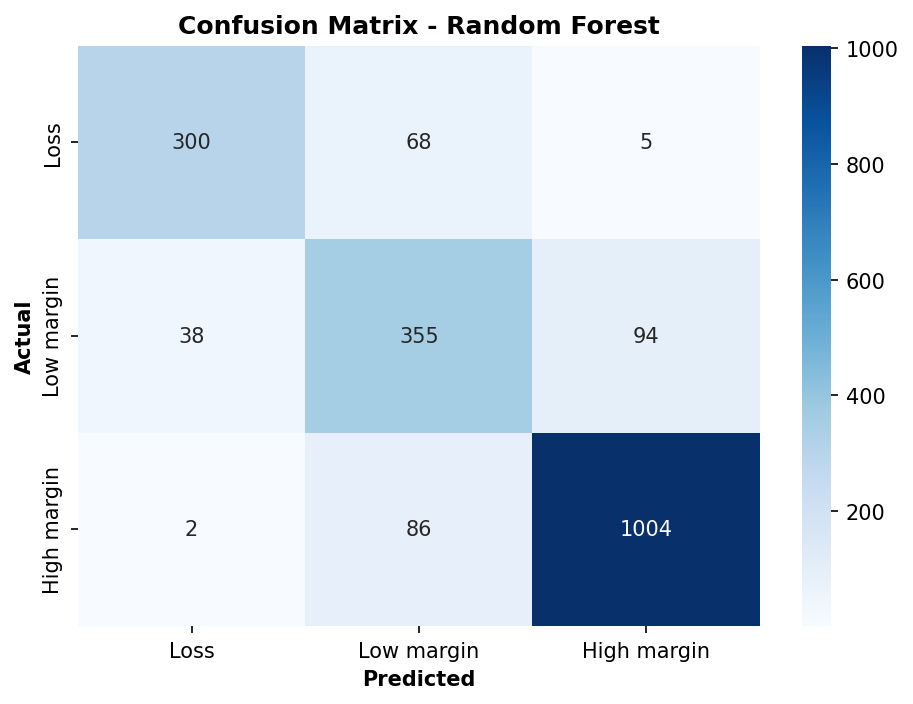

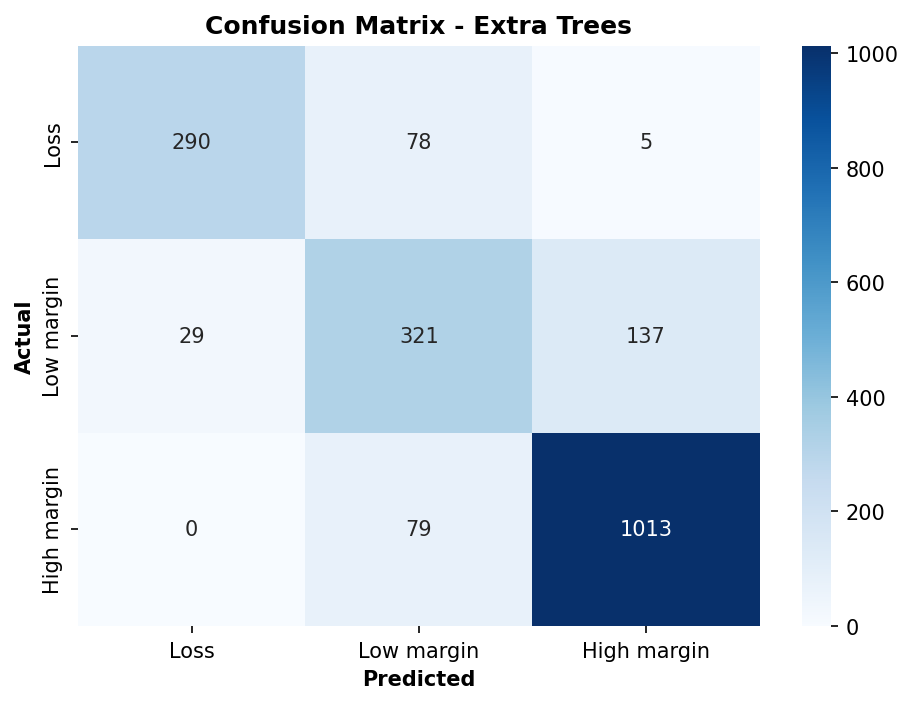

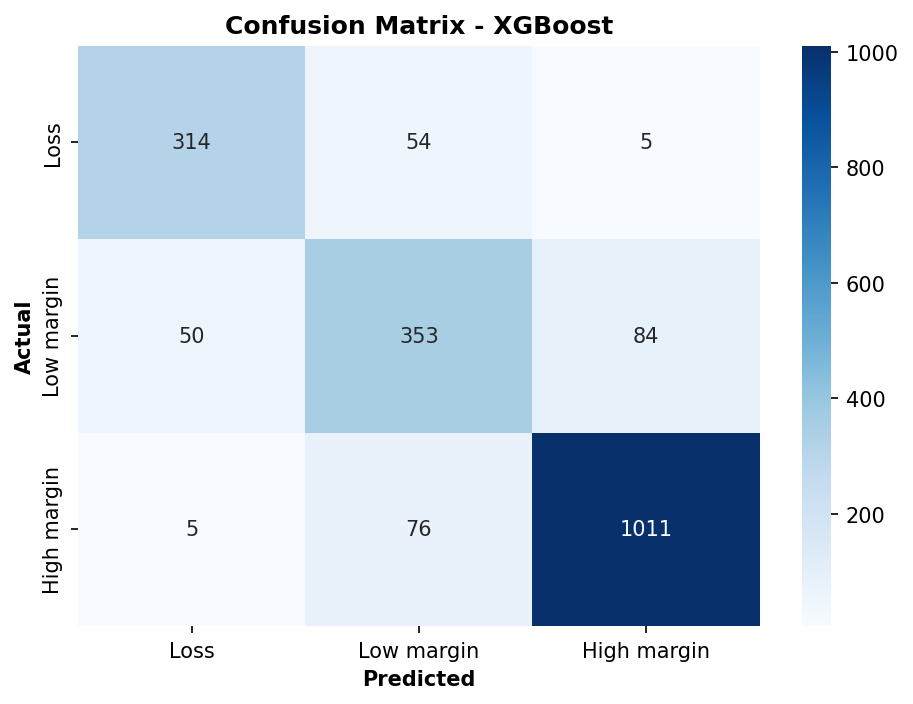

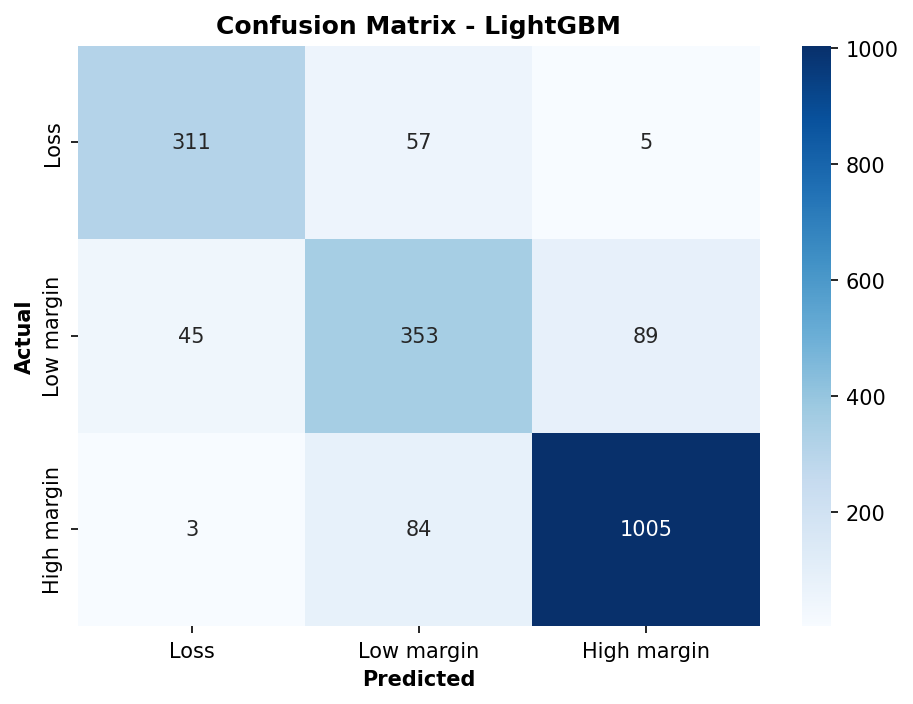

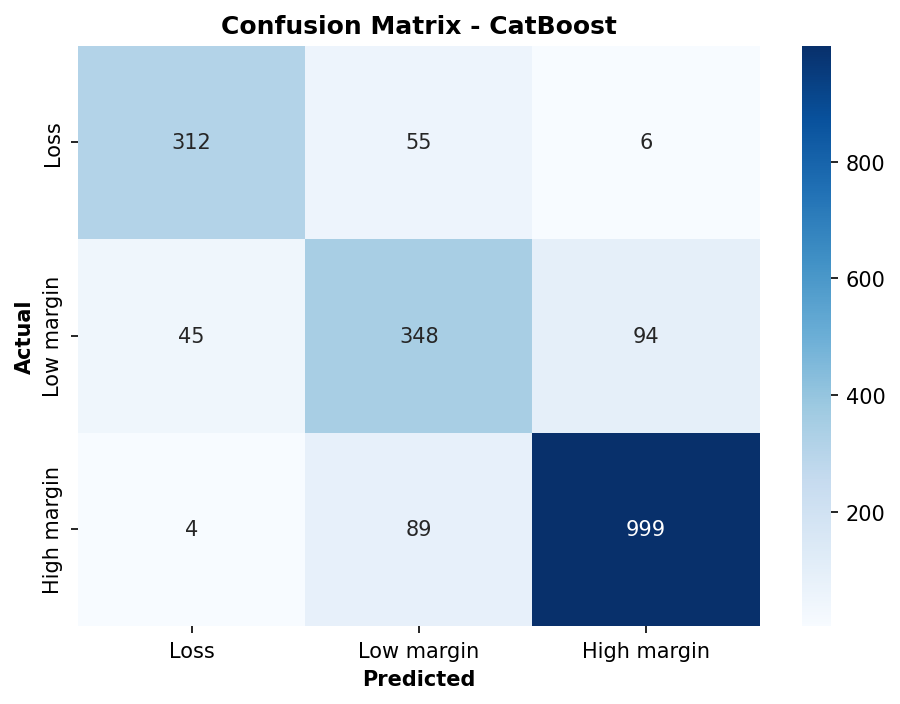

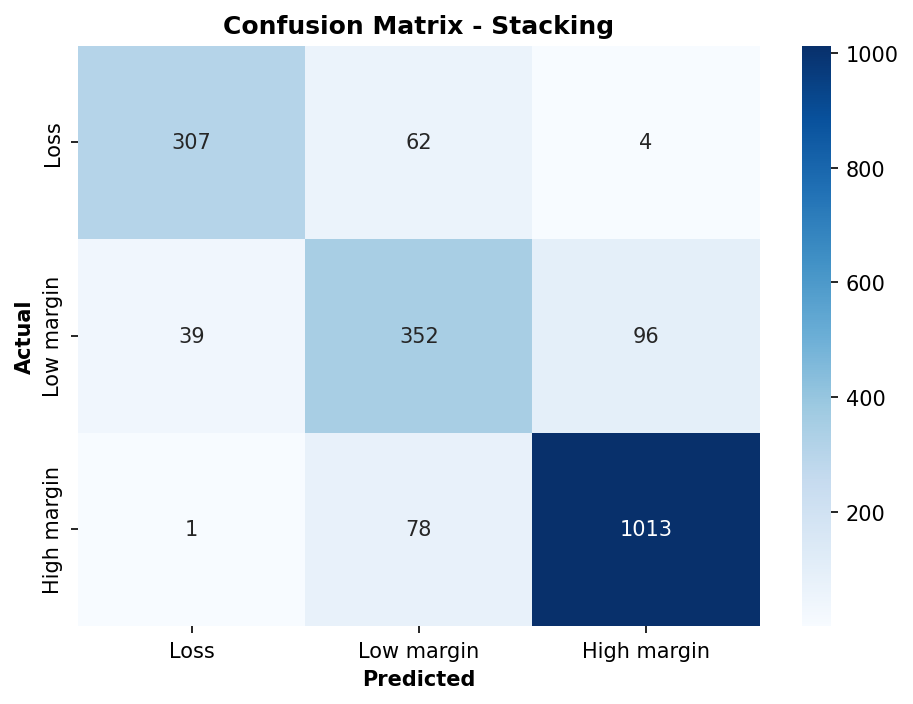

In [12]:
# TASK 6: Visualize — Confusion Matrix (separate plot per model)
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

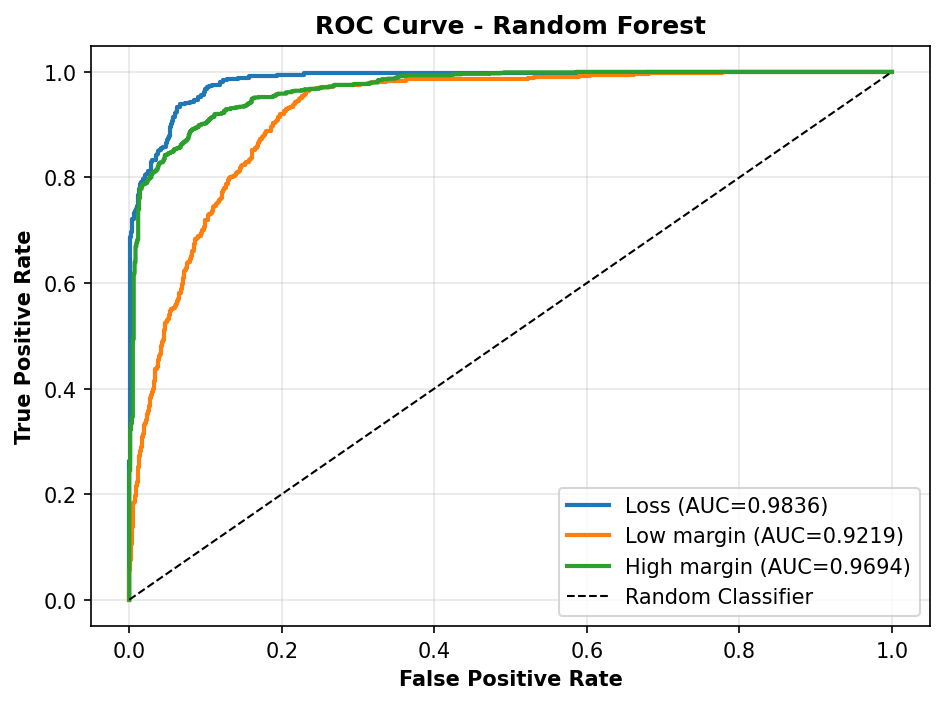

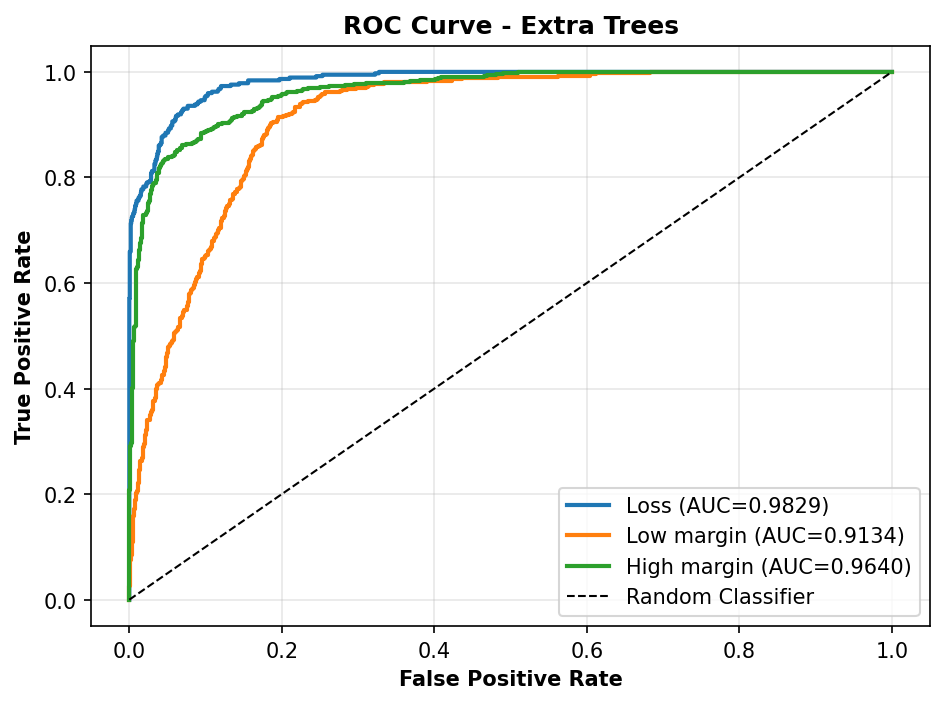

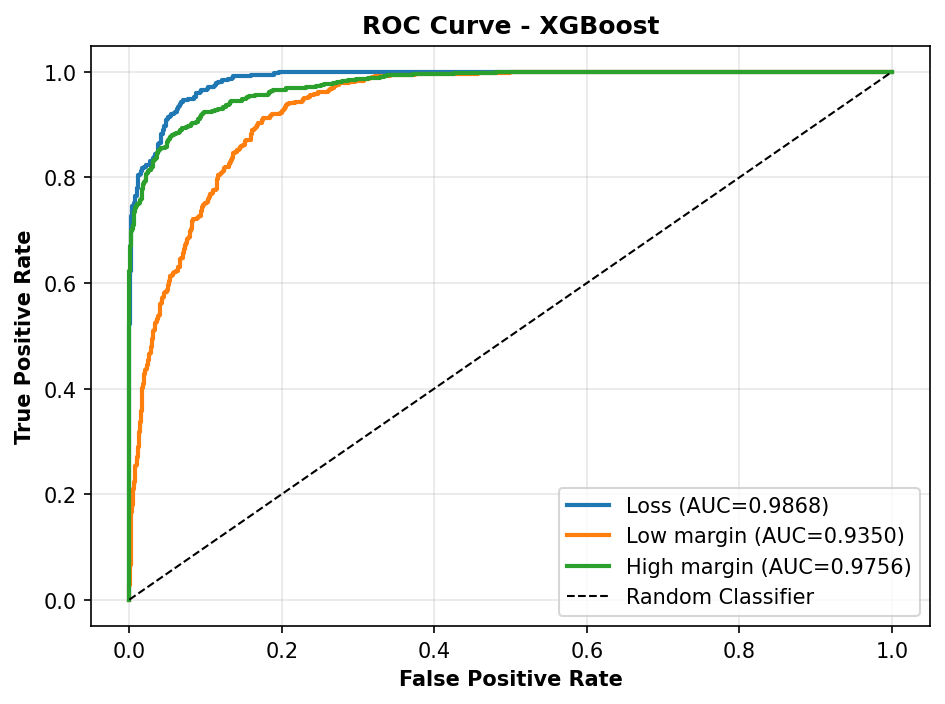

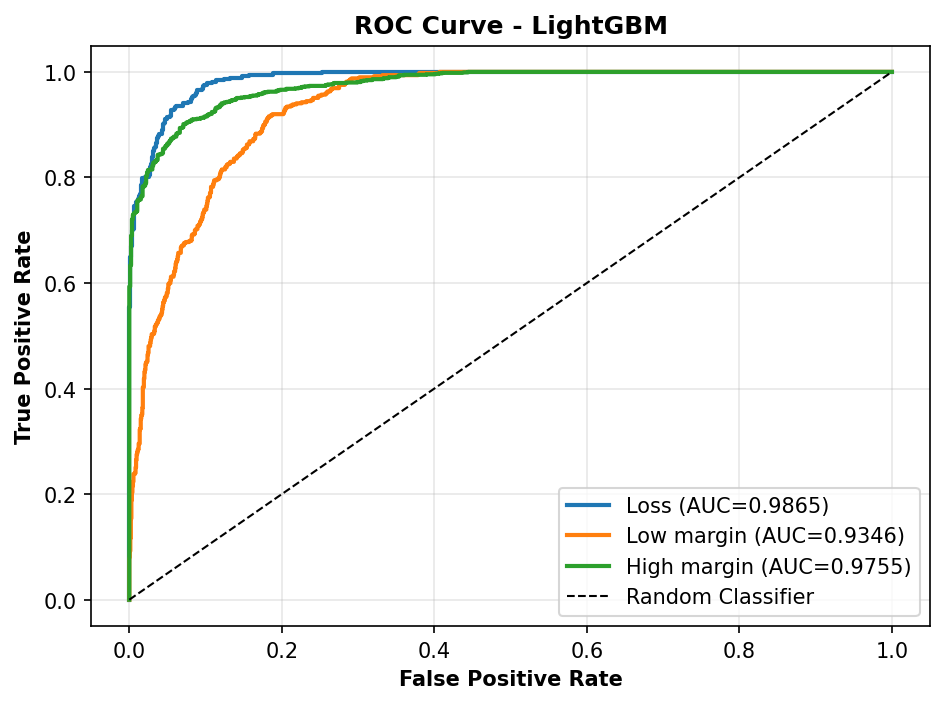

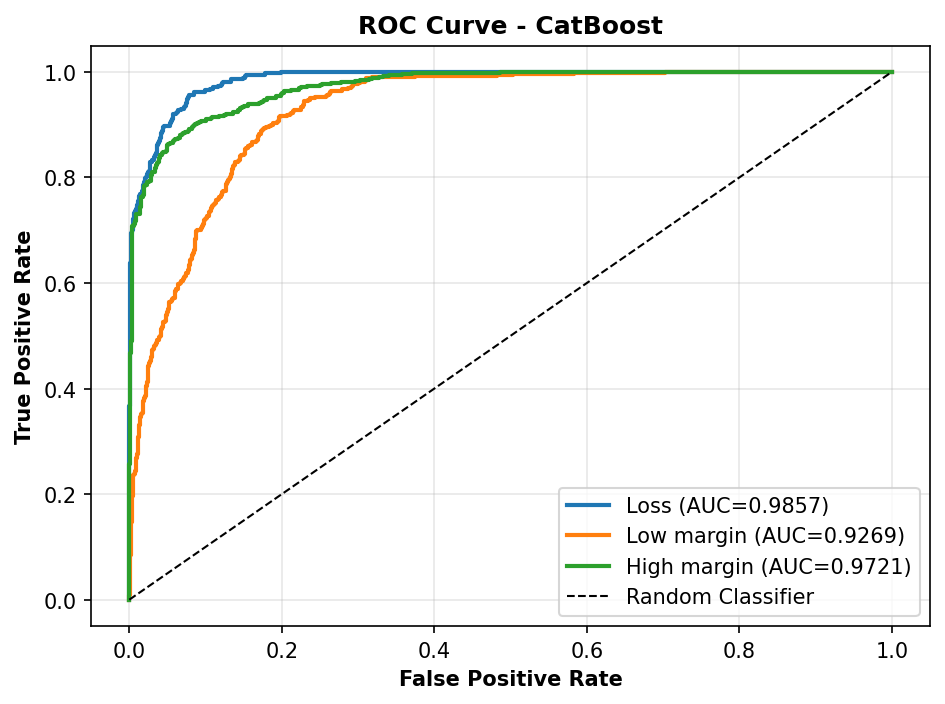

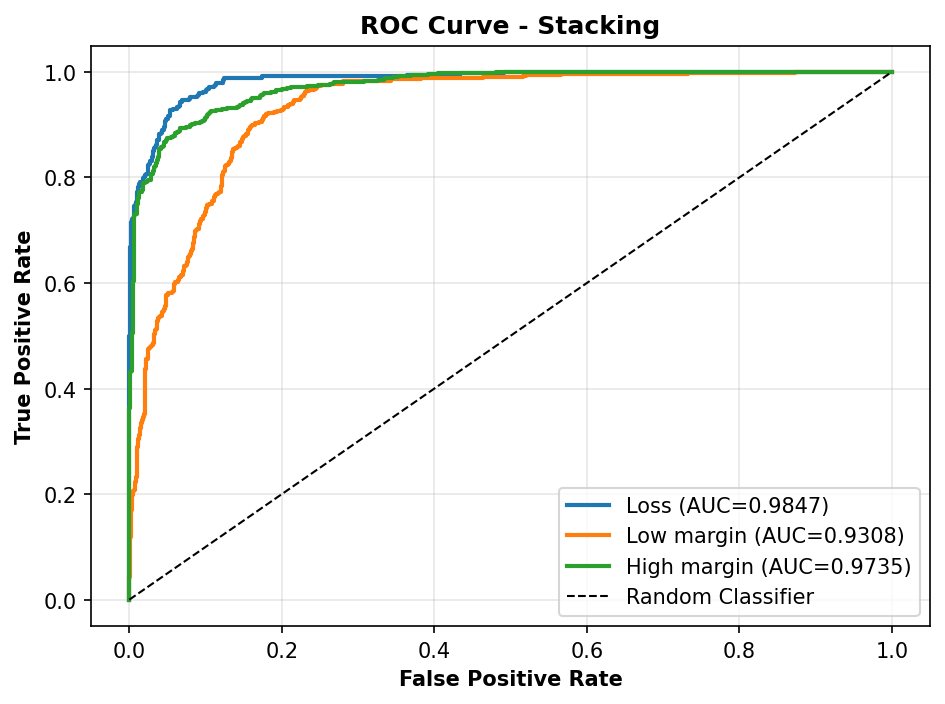

In [13]:
# TASK 6: Visualize — ROC Curve (separate plot per model)
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)

    plt.figure()
    for i, cls_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"{cls_name} (AUC={roc_auc_val:.4f})")

    plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()